# 07 - Error analysis and Grad-CAM

Which test images the three main models get wrong, and which part of the image each model looks at when it decides between fresh and spoiled. Uses the test predictions saved by notebook 06.

In [1]:
import os, sys
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
sys.path.insert(0, os.path.abspath(".."))
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import COMBINED_NAMES, FIGURES_DIR, FRUITS, MODELS_DIR, PREDICTIONS_DIR, PROJECT_ROOT, REPORTS_DIR, SEED
from src.data_pipeline import load_image
from src.evaluation import gradcam, spoiled_prob
%matplotlib inline

In [2]:
MAIN = {"model1_simple_cnn": "Model 1", "model2_multitask_cnn": "Model 2", "model3_mobilenet_v2": "Model 3"}


def load_predictions(run):
    p = pd.read_csv(PREDICTIONS_DIR / f"{run}_test.csv")
    p["fruit_wrong"] = p["fruit_pred"] != p["fruit_label"]
    p["fresh_wrong"] = p["freshness_pred"] != p["freshness_label"]
    p["wrong"] = p["joint_pred"] != p["combined_label"]
    return p


def class_name(label):
    return COMBINED_NAMES[label].replace("_", " ")


preds = {name: load_predictions(run) for run, name in MAIN.items()}

## 1. Error analysis

### Error types

A joint error means that the fruit, the freshness or both are wrong. For freshness, spoiled is the positive class: a *false alarm* is a fresh fruit predicted as spoiled, a *miss* is a spoiled fruit predicted as fresh.

In [3]:
rows = []
for name, p in preds.items():
    fresh = p["freshness_label"] == 0
    rows.append({
        "Model": name,
        "Joint errors": int(p["wrong"].sum()),
        "Fruit only": int((p["fruit_wrong"] & ~p["fresh_wrong"]).sum()),
        "Freshness only": int((p["fresh_wrong"] & ~p["fruit_wrong"]).sum()),
        "Both": int((p["fruit_wrong"] & p["fresh_wrong"]).sum()),
        "False alarms (fresh -> spoiled)": int((p["fresh_wrong"] & fresh).sum()),
        "Misses (spoiled -> fresh)": int((p["fresh_wrong"] & ~fresh).sum()),
    })
error_types = pd.DataFrame(rows)
error_types

,Model,Joint errors,Fruit only,Freshness only,Both,False alarms (fresh -> spoiled),Misses (spoiled -> fresh)
0,Model 1,42,14,22,6,17,11
1,Model 2,45,19,17,9,17,9
2,Model 3,6,0,6,0,2,4


All 6 errors of Model 3 are freshness errors (2 false alarms, 4 misses). Models 1 and 2 also get the fruit type wrong in about half of their errors (20 of 42 and 28 of 45).

### Errors per fruit

In [4]:
base = preds["Model 1"]
per_fruit = pd.DataFrame({"Fruit": FRUITS, "Test images": base.groupby("fruit_label").size().reindex(range(len(FRUITS))).values})
for name, p in preds.items():
    per_fruit[name] = p[p["wrong"]].groupby("fruit_label").size().reindex(range(len(FRUITS)), fill_value=0).values
per_fruit

,Fruit,Test images,Model 1,Model 2,Model 3
0,Banana,300,0,0,0
1,Lemon,232,6,0,0
2,Lulo,232,6,2,2
3,Mango,300,6,8,0
4,Orange,300,0,0,1
5,Strawberry,300,1,2,0
6,Tamarillo,248,9,11,3
7,Tomato,291,14,22,0


Bananas are never misclassified. Tomato and tamarillo are the hardest fruits for the two CNNs trained from scratch.

### Most frequent confusions

In [5]:
rows = []
for name, p in preds.items():
    pairs = p[p["wrong"]].groupby(["combined_label", "joint_pred"]).size().sort_values(ascending=False).head(5)
    rows += [{"Model": name, "True class": class_name(t), "Predicted": class_name(q), "Images": int(n)} for (t, q), n in pairs.items()]
confusions = pd.DataFrame(rows)
confusions

,Model,True class,Predicted,Images
0,Model 1,Lulo fresh,Lulo spoiled,5
1,Model 1,Mango spoiled,Strawberry spoiled,5
2,Model 1,Tomato fresh,Tomato spoiled,4
3,Model 1,Tomato spoiled,Lulo spoiled,4
4,Model 1,Lemon fresh,Lemon spoiled,3
5,Model 2,Tomato fresh,Tamarillo spoiled,7
6,Model 2,Tomato fresh,Tamarillo fresh,6
7,Model 2,Tamarillo fresh,Tamarillo spoiled,6
8,Model 2,Tamarillo spoiled,Tamarillo fresh,4
9,Model 2,Mango fresh,Tamarillo fresh,4


The most common error of Model 2 is a fresh tomato predicted as tamarillo (13 images). The two fruits are related (tamarillo is also called tree tomato) and look alike: red, oval and with shiny skin. Model 1 mixes up spoiled mangoes and spoiled strawberries, and fresh and spoiled lulos.

### Errors shared between the models

In [6]:
wrong = pd.DataFrame({name: p["wrong"] for name, p in preds.items()})
n_models = wrong.sum(axis=1)
rows = [{"Misclassified by": f"exactly {k} model{'s' if k > 1 else ''}", "Images": int((n_models == k).sum())} for k in (1, 2, 3)]
names = list(preds)
for i, a in enumerate(names):
    for b in names[i + 1:]:
        rows.append({"Misclassified by": f"both {a} and {b}", "Images": int((wrong[a] & wrong[b]).sum())})
shared = pd.DataFrame(rows)
shared

,Misclassified by,Images
0,exactly 1 model,61
1,exactly 2 models,16
2,exactly 3 models,0
3,both Model 1 and Model 2,14
4,both Model 1 and Model 3,0
5,both Model 2 and Model 3,2


No test image is misclassified by all three models, and Models 1 and 3 never fail on the same image: the models make different mistakes, the hard images for one model are not hard for the others.

### Confidence of the freshness errors

A prediction counts as uncertain when P(spoiled) is between 0.2 and 0.8.

In [7]:
rows = []
for name, p in preds.items():
    e = p[p["fresh_wrong"]]
    unsure = e["spoiled_prob"].between(0.2, 0.8)
    rows.append({
        "Model": name,
        "Freshness errors": len(e),
        "Uncertain (P(spoiled) 0.2-0.8)": int(unsure.sum()),
        "Confidently wrong": int((~unsure).sum()),
        "Median P(spoiled), false alarms": round(e.loc[e["freshness_label"] == 0, "spoiled_prob"].median(), 2),
        "Median P(spoiled), misses": round(e.loc[e["freshness_label"] == 1, "spoiled_prob"].median(), 2),
    })
confidence = pd.DataFrame(rows)
confidence

,Model,Freshness errors,Uncertain (P(spoiled) 0.2-0.8),Confidently wrong,"Median P(spoiled), false alarms","Median P(spoiled), misses"
0,Model 1,28,15,13,0.79,0.29
1,Model 2,26,12,14,0.88,0.19
2,Model 3,6,1,5,0.71,0.08


About half of the freshness errors of Models 1 and 2 are uncertain, while 5 of the 6 errors of Model 3 are confident. Its misses have a median P(spoiled) of only 0.08: on these images the model sees no sign of spoilage at all.

### Every test error of Model 3

In [8]:
p = preds["Model 3"]
e = p[p["wrong"]]
errors_m3 = pd.DataFrame({
    "Image": e["path"].str.replace("data/raw/FRUIT-16K/", "", regex=False),
    "True class": e["combined_label"].map(class_name),
    "Predicted": e["joint_pred"].map(class_name),
    "P(spoiled)": e["spoiled_prob"].round(2),
    "P(true fruit)": [round(r[f"p_{FRUITS[r['fruit_label']]}"], 2) for _, r in e.iterrows()],
})
errors_m3

,Image,True class,Predicted,P(spoiled),P(true fruit)
555,F_Orange/642.jpg,Orange fresh,Orange spoiled,0.81,1.0
808,F_Tamarillo/619.jpg,Tamarillo fresh,Tamarillo spoiled,0.61,1.0
1314,S_Lulo/28.jpg,Lulo spoiled,Lulo fresh,0.07,1.0
1356,S_Lulo/345.jpg,Lulo spoiled,Lulo fresh,0.00,0.8
2023,S_Tamarillo/762.jpg,Tamarillo spoiled,Tamarillo fresh,0.10,1.0
2024,S_Tamarillo/763.jpg,Tamarillo spoiled,Tamarillo fresh,0.09,1.0


Four spoiled fruits (two lulos, two tamarillos) are called fresh with high confidence, and two fresh fruits are called spoiled. The two false alarms are the "hard cases" of the demo (notebook 08).

The tables are saved to `reports/error_analysis.md`:

In [9]:
def md(df):
    lines = ["| " + " | ".join(map(str, df.columns)) + " |", "|" + "---|" * len(df.columns)]
    return "\n".join(lines + ["| " + " | ".join(map(str, row)) + " |" for row in df.itertuples(index=False)])


text = [
    f"# Error analysis (test split, {len(base):,} images)", "",
    "Joint error = fruit type or freshness (or both) wrong. Freshness: spoiled is the positive class, so a",
    "false alarm is a fresh fruit predicted spoiled and a miss is a spoiled fruit predicted fresh.",
    "Made by notebooks/07_error_analysis_gradcam.ipynb; images of the errors: figures/misclassified_samples.png,",
    "Grad-CAM of the freshness errors: figures/gradcam/gradcam_errors.png.", "",
    "## Error types", "", md(error_types), "",
    "## Joint errors per fruit", "", md(per_fruit), "",
    "## Most frequent confusions", "", md(confusions), "",
    "## Errors shared between the models", "", md(shared), "",
    "## Confidence of the freshness errors", "", md(confidence), "",
    "## Every test error of Model 3", "", md(errors_m3), "",
]
(REPORTS_DIR / "error_analysis.md").write_text("\n".join(text), encoding="utf-8")

2947

## 2. Grad-CAM

Grad-CAM (Selvaraju et al., 2017) shows which regions of the image push the model towards its answer:

1. take the feature maps of the last convolutional layer (Model 1: 14 x 14 x 256, Model 2: 7 x 7 x 512, Model 3: 7 x 7 x 1280);
2. compute the gradient of the score of the predicted freshness class with respect to these maps;
3. average the gradient of each channel over the image: this is the importance weight of the channel;
4. add up the channels with these weights, keep the positive part (ReLU) and upsample the map to 224 x 224.

The score is taken before the sigmoid/softmax, because very confident outputs saturate and their gradients are almost zero (`gradcam()` in `src/evaluation.py`).

In [10]:
models = {name: keras.models.load_model(MODELS_DIR / f"{run}.keras") for run, name in MAIN.items()}
OUT = FIGURES_DIR / "gradcam"


def show_cam(ax, image, heat=None, title=""):
    # chồng heatmap Grad-CAM lên ảnh: màu đỏ = vùng ảnh hưởng mạnh nhất tới dự đoán
    ax.imshow(image.astype("uint8"))
    if heat is not None:
        ax.imshow(heat, cmap="jet", alpha=0.4)
    ax.set_title(title, fontsize=8)
    ax.axis("off")


def examples(state):
    # mỗi loại quả lấy ngẫu nhiên 1 ảnh test mà cả 3 model đều đoán đúng
    rng = np.random.default_rng(SEED)
    ok = np.logical_and.reduce([~p["wrong"].to_numpy() for p in preds.values()])
    target = int(state == "spoiled")
    picks = []
    for f in range(len(FRUITS)):
        pool = base[ok & (base.fruit_label == f).to_numpy() & (base.freshness_label == target).to_numpy()]
        picks.append(pool.iloc[rng.integers(len(pool))])
    return pd.DataFrame(picks)


def cam_grid(picks, title):
    images = np.stack([load_image(PROJECT_ROOT / path) for path in picks["path"]])
    fig, axes = plt.subplots(1 + len(models), len(picks), figsize=(2 * len(picks), 2.2 * (1 + len(models))))
    for c, fruit in enumerate(picks["fruit_label"]):
        show_cam(axes[0, c], images[c], title=FRUITS[fruit])
    for row, (name, model) in enumerate(models.items(), start=1):
        heat, prob = gradcam(model, images, "freshness"), spoiled_prob(model, images)
        for c in range(len(picks)):
            show_cam(axes[row, c], images[c], heat[c], f"{name}: P(spoiled) {prob[c]:.2f}")
    fig.suptitle(title)
    plt.tight_layout()
    return fig

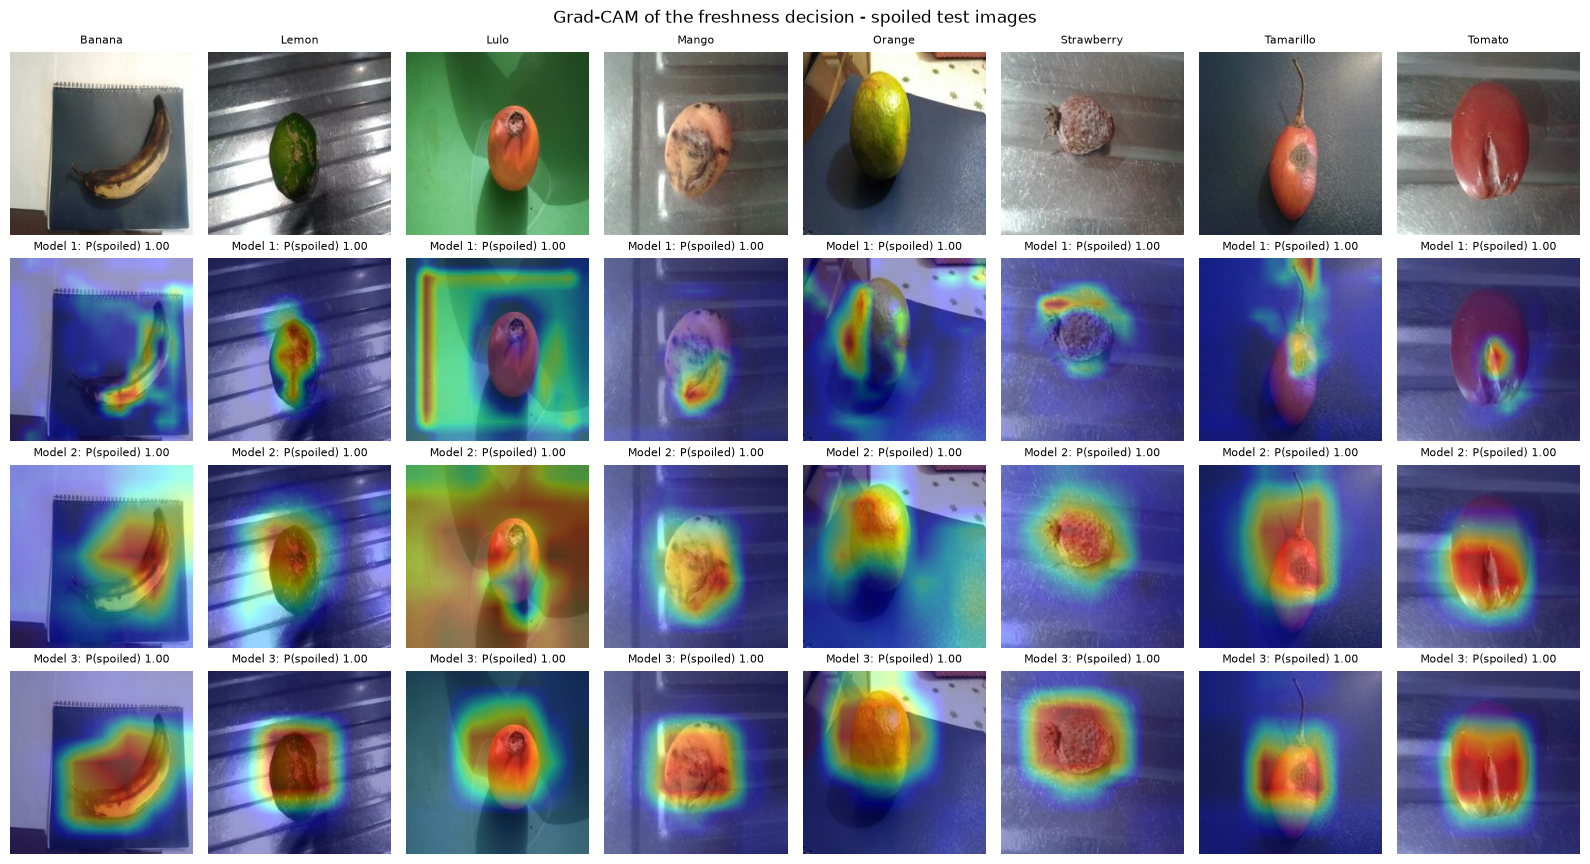

In [11]:
fig = cam_grid(examples("spoiled"), "Grad-CAM of the freshness decision - spoiled test images")
fig.savefig(OUT / "gradcam_spoiled.png", dpi=150, bbox_inches="tight")

For spoiled fruits Model 3 always looks at the fruit itself; its last feature map is only 7 x 7, so the heatmap is coarse and covers the whole fruit. Models 1 and 2 often look at the fruit too, but sometimes at the background or the edge of the image (for example the lulo and the orange).

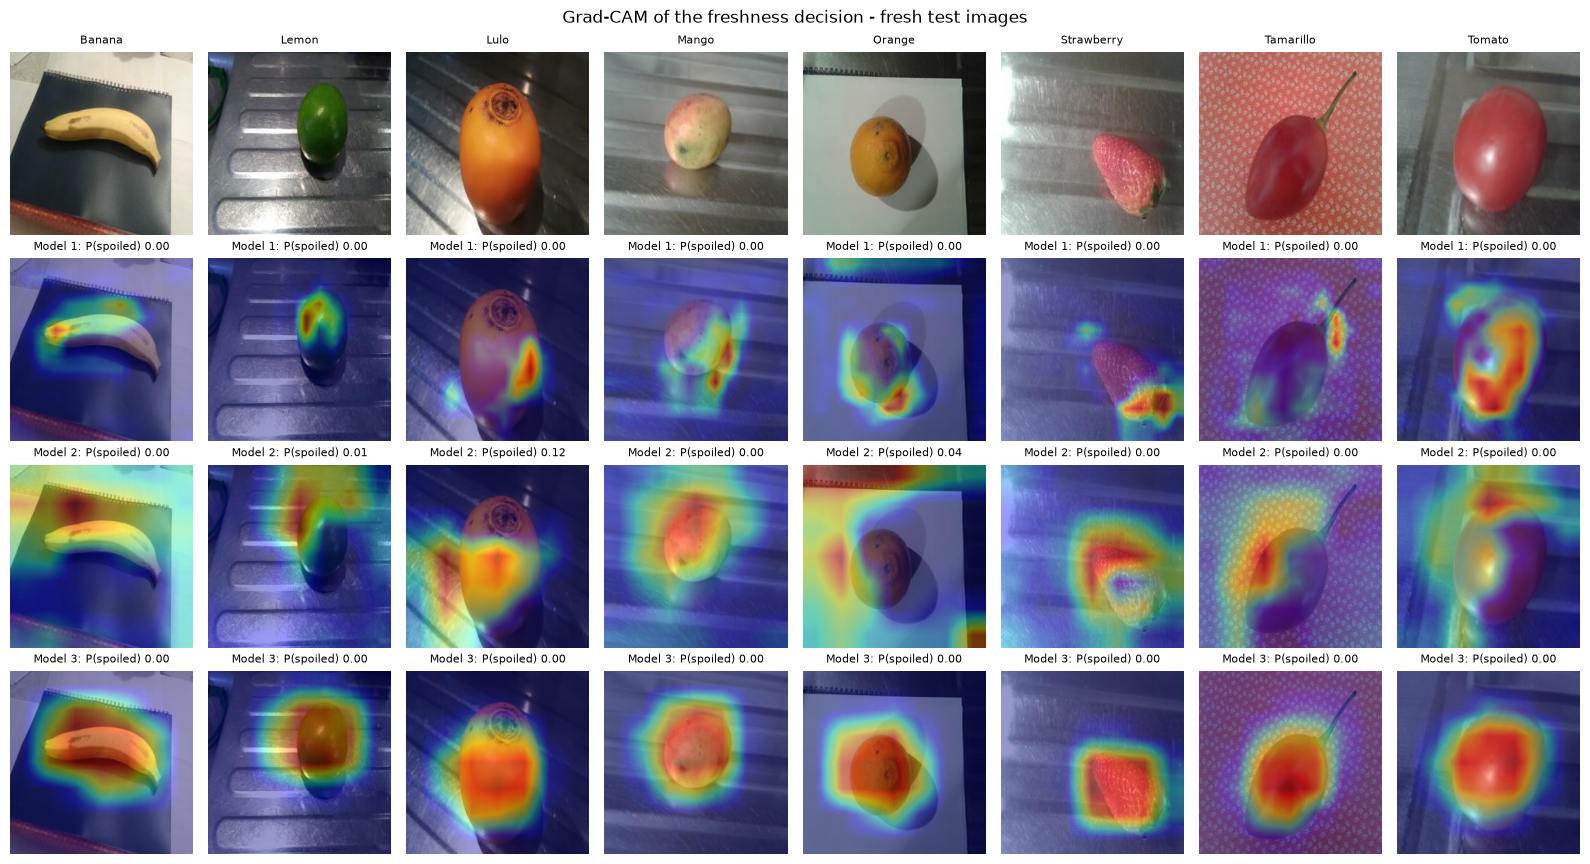

In [12]:
fig = cam_grid(examples("fresh"), "Grad-CAM of the freshness decision - fresh test images")
fig.savefig(OUT / "gradcam_fresh.png", dpi=150, bbox_inches="tight")

For fresh fruits the evidence is more spread over the whole fruit: there is no single spot that proves freshness, it is rather the absence of damage.

### Freshness errors

Up to six random freshness errors per model, each image with its heatmap below.

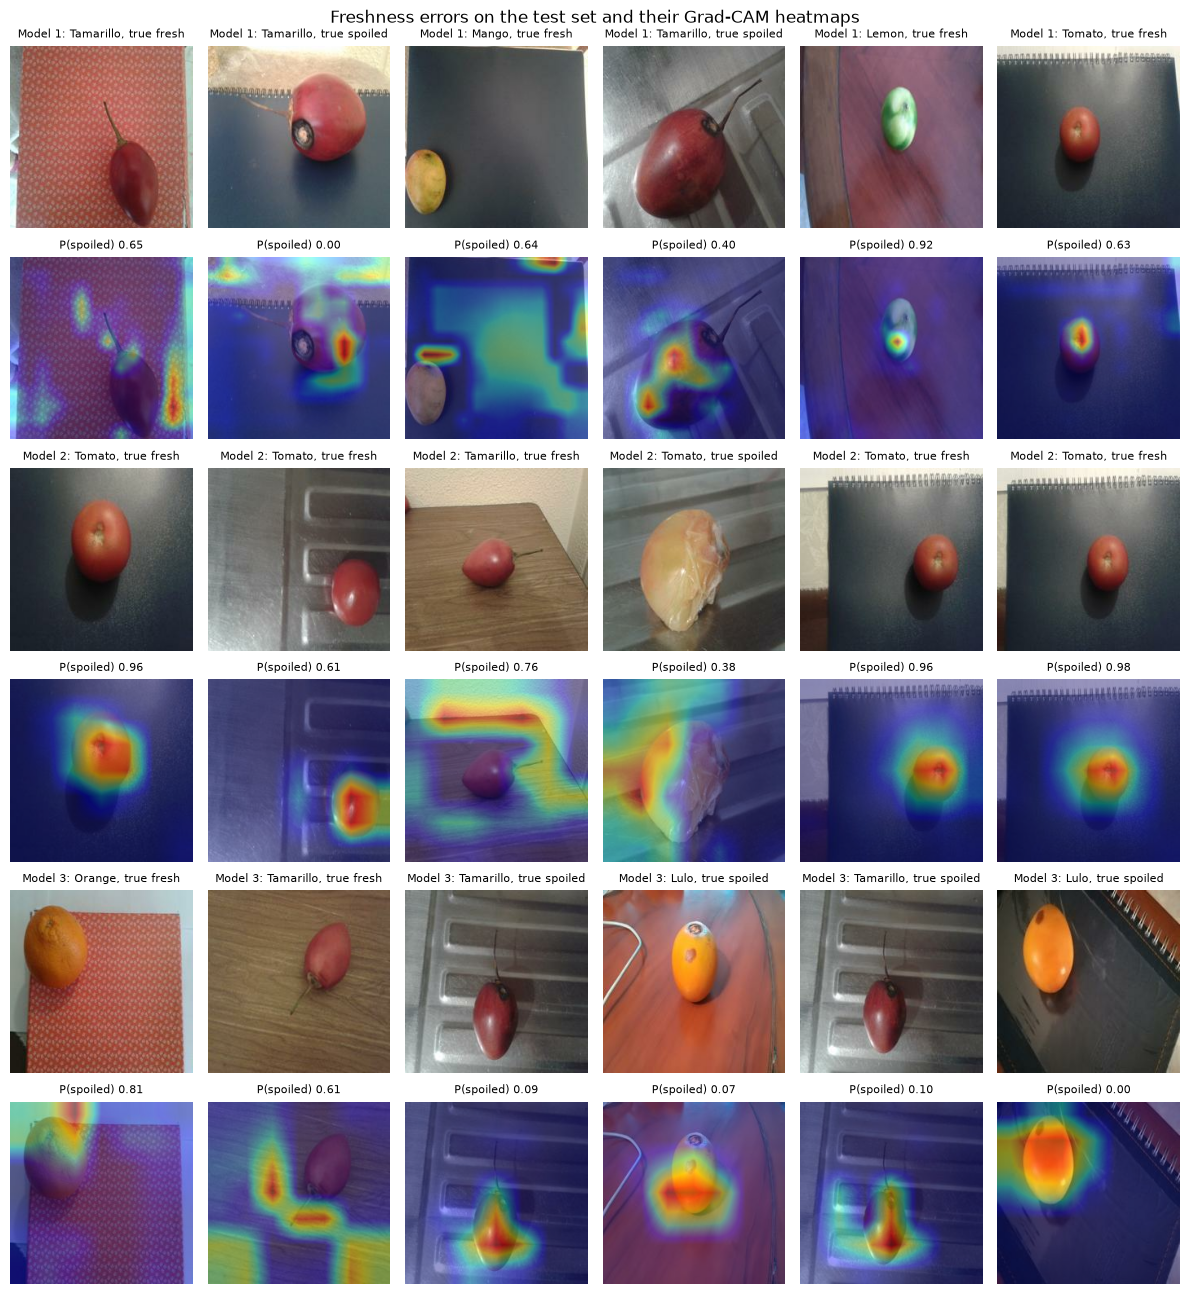

In [13]:
per_model = 6
fig, axes = plt.subplots(2 * len(models), per_model, figsize=(2 * per_model, 2.2 * 2 * len(models)))
for ax in axes.ravel():
    ax.axis("off")
for m, (name, model) in enumerate(models.items()):
    p = preds[name]
    errs = p[p["fresh_wrong"]].sample(min(per_model, int(p["fresh_wrong"].sum())), random_state=SEED)
    images = np.stack([load_image(PROJECT_ROOT / path) for path in errs["path"]])
    heat = gradcam(model, images, "freshness")
    for c, r in enumerate(errs.itertuples()):
        true = "spoiled" if r.freshness_label else "fresh"
        show_cam(axes[2 * m, c], images[c], title=f"{name}: {FRUITS[r.fruit_label]}, true {true}")
        show_cam(axes[2 * m + 1, c], images[c], heat[c], f"P(spoiled) {r.spoiled_prob:.2f}")
fig.suptitle("Freshness errors on the test set and their Grad-CAM heatmaps")
plt.tight_layout()
fig.savefig(OUT / "gradcam_errors.png", dpi=150, bbox_inches="tight")

In several misses the spoiled part is small or on the side of the fruit that is not visible, and in the false alarms the model reacts to reflections or natural marks on the skin.

### The two heads of Model 3

Grad-CAM of the fruit head (score = logit of the predicted fruit) and of the freshness head on the same images.

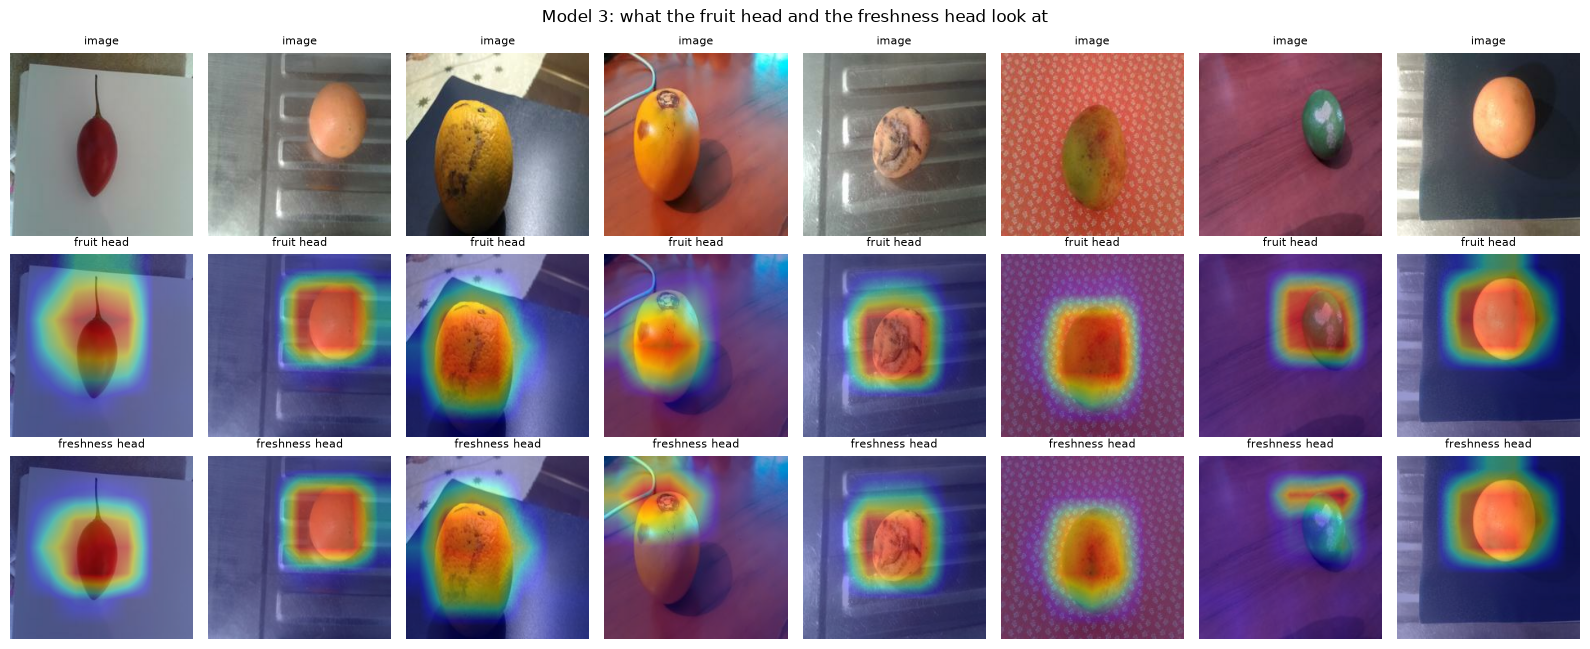

In [14]:
sample = preds["Model 3"].sample(n=8, random_state=SEED)
images = np.stack([load_image(PROJECT_ROOT / path) for path in sample["path"]])
model3 = models["Model 3"]
fruit_heat, fresh_heat = gradcam(model3, images, "fruit"), gradcam(model3, images, "freshness")
fig, axes = plt.subplots(3, 8, figsize=(16, 6.6))
for c in range(8):
    show_cam(axes[0, c], images[c], title="image")
    show_cam(axes[1, c], images[c], fruit_heat[c], "fruit head")
    show_cam(axes[2, c], images[c], fresh_heat[c], "freshness head")
fig.suptitle("Model 3: what the fruit head and the freshness head look at")
plt.tight_layout()
fig.savefig(OUT / "gradcam_heads_model3.png", dpi=150, bbox_inches="tight")

Both heads share the same backbone but use it differently: the fruit head looks at the shape and colour of the whole fruit, the freshness head at local damage.